### Otsu's Method of global Thresholding

In [1]:
import cv2
import numpy as np
from utils import print_image, compute_histogram
import matplotlib.pyplot as plt

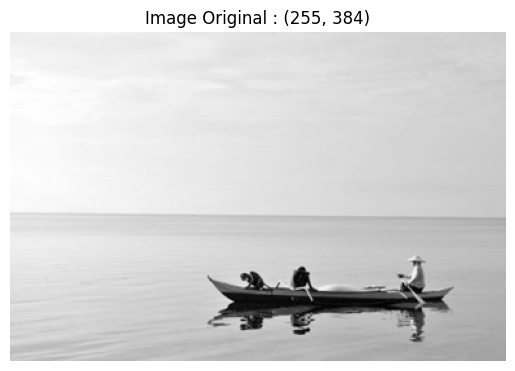

In [2]:
img = cv2.imread('Images/Boat.jpeg', cv2.IMREAD_GRAYSCALE)
print_image(img, 'Original')

In [3]:
MN = img.shape[0] * img.shape[1]
histogram = np.array(compute_histogram(img))
MN

97920

Text(0.5, 1.0, 'Histogram of the Image')

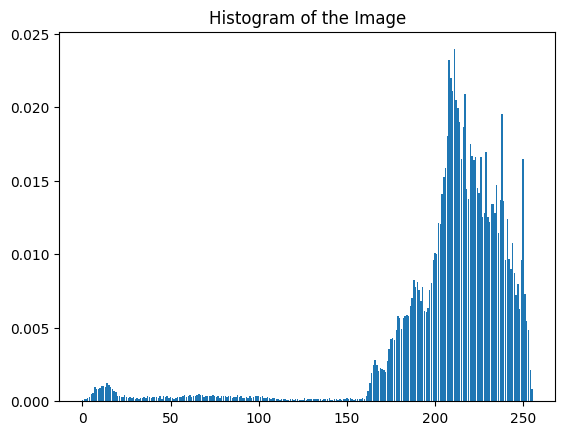

In [4]:
plt.bar(range(256), histogram)
plt.title('Histogram of the Image')

In [5]:
MG = mG = sum(i * histogram[i] for i in range(256))
print(f'Mean Gray Level (MG): {MG:.2f}')

Mean Gray Level (MG): 208.39


In [6]:
## Finding max k for global threshold
def otsu_threshold(histogram, total_pixels):  
    max_sigma_b = -1.0
    threshold = 0
    
 
    p1 = 0.0  
    mk = 0.0 
    
    for k in range(256):
  
        p1 += histogram[k] / total_pixels
        mk += (k * histogram[k]) / total_pixels
        
        
        num = (mG * p1 - mk) ** 2
        den = p1 * (1 - p1) + 2.5 * 1e-8
        sigma_b_2 = num / den
        
        if sigma_b_2 >= max_sigma_b:
            max_sigma_b = sigma_b_2
            threshold = k
            
    return threshold
            

In [7]:
k = otsu_threshold(histogram, MN)
k

134

In [8]:
new_img = np.zeros_like(img)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if img[i, j] > k:
            new_img[i, j] = 255
        else:
            new_img[i, j] = 0

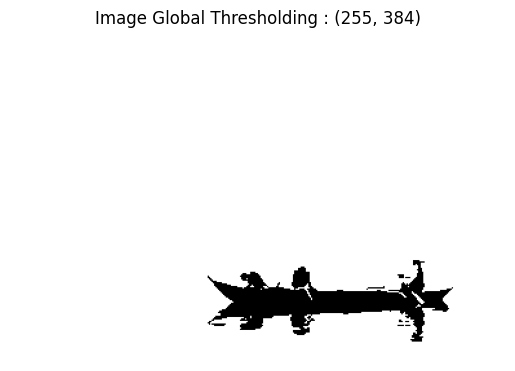

In [9]:
print_image(new_img, 'Global Thresholding')

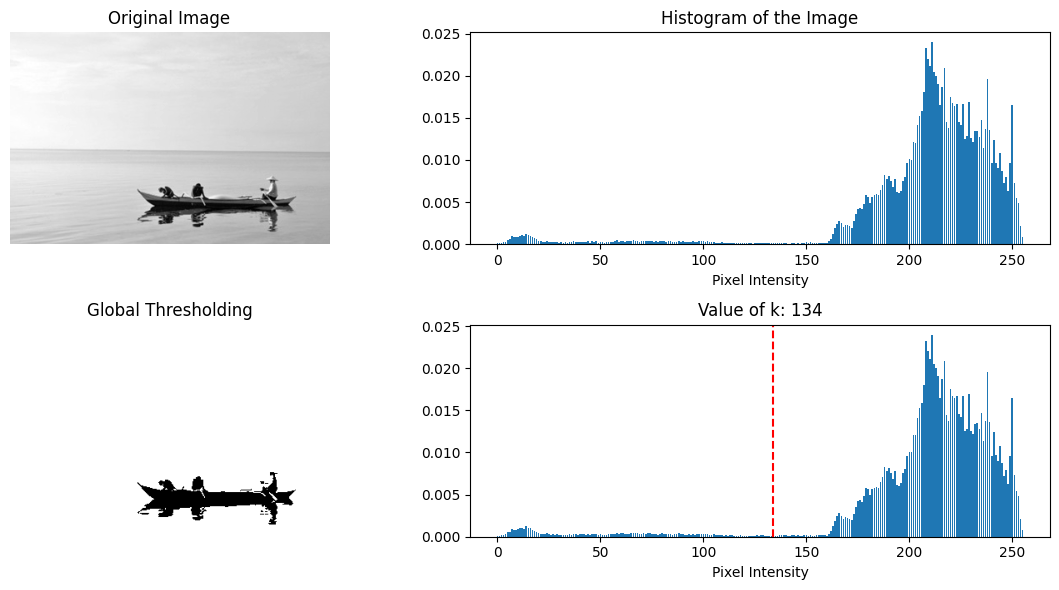

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

# Original Image
ax[0, 0].imshow(img, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

# Histogram
ax[0, 1].bar(range(256), histogram)
ax[0, 1].set_title('Histogram of the Image')
ax[0, 1].set_xlabel('Pixel Intensity')

# Thresholded Image
ax[1, 0].imshow(new_img, cmap='gray')
ax[1, 0].set_title('Global Thresholding')
ax[1, 0].axis('off')

# Histogram with Threshold
ax[1, 1].bar(range(256), histogram)
ax[1, 1].axvline(x=k, color='red', linestyle='--', label=f'Threshold (k={k})')
ax[1, 1].set_title('Histogram with Otsu Threshold')
ax[1, 1].set_xlabel('Pixel Intensity')

plt.tight_layout()
plt.title(f"Value of k: {k}")
plt.show()